In [41]:
import math
from typing import Dict, List, Tuple

# You can adjust this limit as needed
MAX_SIMULATE_CNT = 10**6

Fractor = Tuple[int, int]          # (numerator, denominator)
Fractors = List[Fractor]
KEY = Tuple[int, int, int]         # (init_pos, max_denom, apply_frac_cnt)


def reduce_fraction(fr: Fractor) -> Fractor:
    """Reduce a fraction to lowest terms, handling the (-1, -1) sentinel."""
    n, d = fr
    if n == -1 and d == -1:
        return (-1, -1)
    g = math.gcd(n, d)
    return (n // g, d // g)


def mul_fracs(fr_list: Fractors) -> Fractor:
    """Multiply a list of fractions and reduce the result."""
    num, den = 1, 1
    for n, d in fr_list:
        num *= n
        den *= d
    return reduce_fraction((num, den))


def make_sorted_indices(rates: List[float]) -> List[int]:
    """Return the indices that would sort the rates ascending."""
    return sorted(range(len(rates)), key=lambda i: rates[i])


class FractorManager:
    def __init__(self, max_denominators: List[int]):
        # Maps KEY -> list of Fractors lists
        self.fractor_map: Dict[KEY, List[Fractors]] = {}
        # Maps KEY -> list of corresponding rates
        self.rates_map: Dict[KEY, List[float]] = {}

        for max_denom in max_denominators:
            # precompute for 1 and 2 applied fractions
            self.construct(max_denom, apply_frac_cnt=1)
            self.construct(max_denom, apply_frac_cnt=2)

    def calc_rate(self, fractors: Fractors) -> float:
        rate = 1.0
        for n, d in fractors:
            if n == -1:
                return 0.0
            rate *= n / d
        return rate

    def construct(self, max_denom: int, apply_frac_cnt: int):
        fractors_list: List[Fractors] = []
        rates_list: List[float] = []

        # 全開放
        fractors_list.append([(1, 1)])
        rates_list.append(1.0)

        # 何もしない
        fractors_list.append([(-1, -1)])
        rates_list.append(0.0)

        # decide step size to limit simulation count
        MAX_STEP = 1
        # simulate_cnt = max_denom ** 5
        # if simulate_cnt > MAX_SIMULATE_CNT:
        #     div = simulate_cnt / MAX_SIMULATE_CNT
        #     MAX_STEP = max(1, int(round(div ** (1.0 / 5.0))))

        seen: set = set()
        for init_pos in range(0, -1, -1):
            for fr_cnt in range(apply_frac_cnt):
                if fr_cnt == 0:
                    # 分数1回適応
                    for denom in range(max(2, init_pos), max_denom + 1):
                        for num in range(1, denom):
                            fr = (num, denom)
                            red = reduce_fraction(fr)
                            if red in seen:
                                continue
                            seen.add(red)
                            fractors_list.append([fr])
                            rates_list.append(self.calc_rate(fractors_list[-1]))
                else:
                    # 分数2回適応
                    for d1 in range(max(2, init_pos + 1), max_denom + 1, MAX_STEP):
                        for n1 in range(1, d1, MAX_STEP):
                            f1 = (n1, d1)
                            min_d2 = max(2, n1)
                            max_d2 = n1 + (max_denom - d1)
                            for d2 in range(min_d2, max_d2 + 1, MAX_STEP):
                                for n2 in range(1, d2, MAX_STEP):
                                    f2 = (n2, d2)
                                    prod = mul_fracs([f1, f2])
                                    if prod in seen:
                                        continue
                                    seen.add(prod)
                                    fractors_list.append([f1, f2])
                                    rates_list.append(self.calc_rate(fractors_list[-1]))

            # sort for binary search
            inds = make_sorted_indices(rates_list)
            fractors_list = [fractors_list[i] for i in inds]
            rates_list    = [rates_list[i]    for i in inds]

            key: KEY = (init_pos, max_denom, apply_frac_cnt)
            self.fractor_map[key] = fractors_list.copy()
            self.rates_map[key]   = rates_list.copy()

    def get_fractors(self, pos: int, max_denom: int, apply_frac_cnt: int) -> List[Fractors]:
        key = (pos, max_denom, apply_frac_cnt)
        return self.fractor_map[key]

    def get_rates(self, pos: int, max_denom: int, apply_frac_cnt: int) -> List[float]:
        key = (pos, max_denom, apply_frac_cnt)
        return self.rates_map[key]

    def get(self, pos: int, max_denom: int, apply_frac_cnt: int, i: int) -> Tuple[float, Fractors]:
        key = (pos, max_denom, apply_frac_cnt)
        return self.rates_map[key][i], self.fractor_map[key][i]


In [42]:
manager = FractorManager([80])

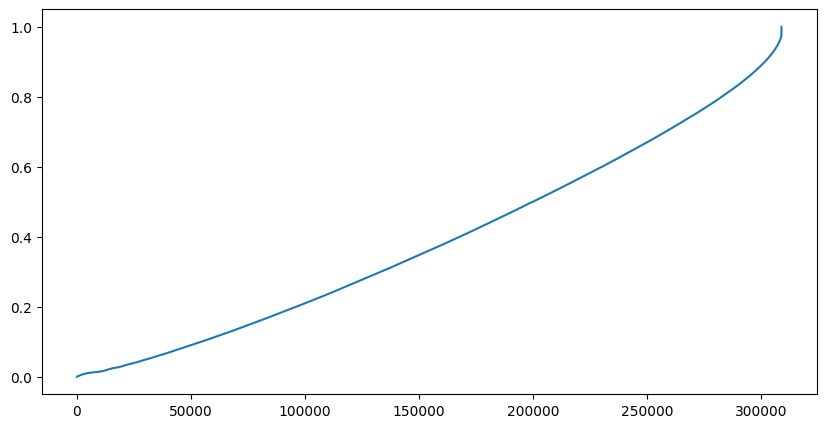

In [ ]:
rates = manager.get_rates(0, 80, 2)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(rates)
plt.show()

In [44]:
len(rates)

308838

In [ ]:
from fractions import Fraction


def farey(n):
    a, b, c, d = 0, 1, 1, n
    yield Fraction(a, b)
    while c <= n:
        k = (n + b) // d
        a, b, c, d = c, d, k * c - a, k * d - b
        yield Fraction(a, b)

class FractorManagerFast:
    def __init__(self, max_denominators):
        self.S1_map = {}  # max_denom -> list of S1
        for m in max_denominators:
            self.S1_map[m] = list(farey(m))

    def get_unique_products(self, max_denom, times=2):
        S1 = self.S1_map[max_denom]
        result = set(S1)
        for _ in range(times - 1):
            # result ← { x*y : x∈result, y∈S1 }
            result = { x * y for x in result for y in S1 }
        # ソートして返したいなら
        return sorted(result)

# 使い方
fm = FractorManagerFast([80])
unique_one = fm.get_unique_products(80, times=1)  # 1回適用後
unique_two = fm.get_unique_products(80, times=2)  # 2回適用後

In [48]:
len(unique_two)

540675